In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D,AveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# plot settings
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

In [53]:
import matplotlib.pyplot as plt
import importlib

importlib.reload(plt)

print(type(plt.xlabel))

<class 'function'>


# Task 1
## Load CIFAR-10.
## Print dataset dimensions.

In [2]:
(X_train,y_train), (X_test,y_test) = cifar10.load_data()
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1557s 9us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


## Display ten sample images.


In [4]:
# Define class categories
class_names=["Airplane","Automobile","Bird","Cat","Deer","Dog","Frog","Horse","Ship","Truck"]

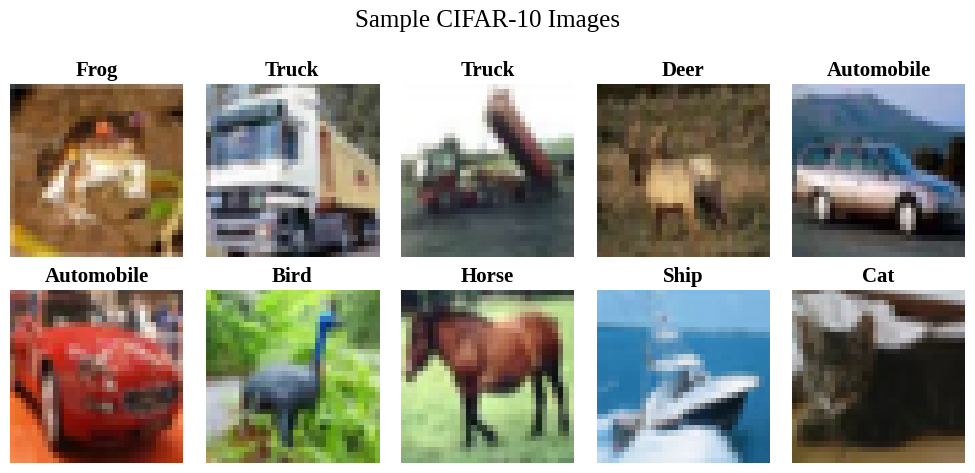

In [5]:
# Plot sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("SampleImages.png")
plt.show()

## Plot class distribution.

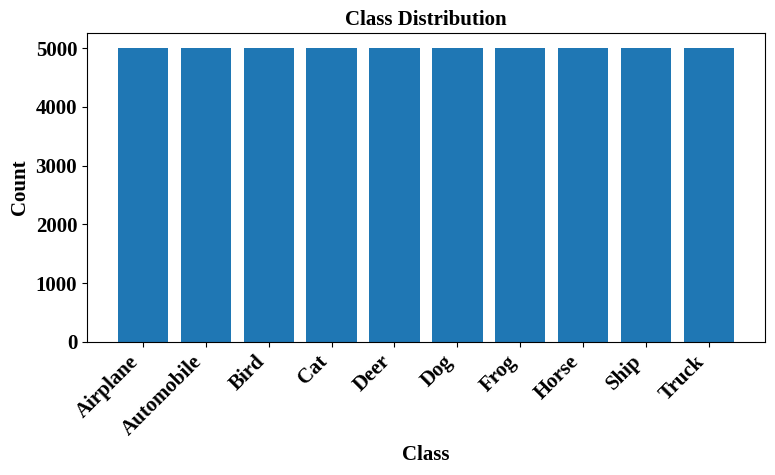

In [54]:
# Plot class distribution
unique,counts = np.unique(y_train,return_counts=True)
plt.figure(figsize=(8,5))
plt.bar(class_names,counts)

plt.xticks(
    ticks=range(10),
    labels=class_names,
    rotation=45,
    ha="right"
)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("ClassDistribution.png")
plt.show()

In [52]:
print(plt.xlabel)
print(plt.ylabel)

<bound method _AxesBase.set_xlabel of <Axes: xlabel='Class', ylabel='Count'>>
<bound method _AxesBase.set_ylabel of <Axes: xlabel='Class', ylabel='Count'>>


In [7]:
# Normalise images
X_train = X_train/ 255.0
X_test = X_test/ 255.0

In [8]:
# Apply one-hot encoding to class labels
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

# Task 2
## Implement a convolution layer.
## Compare
1. Kernel = 3 × 3
2. Kernel = 5 × 5
3. Kernel = 7 × 7

## Record feature map sizes

In [9]:
print("Kernel Size Comparison")
for k in [3, 5, 7]:
    temp_model = Sequential()
    temp_model.add(
        Conv2D(
            filters=32,
            kernel_size=(k, k),
            strides=(1,1),
            padding='same',
            input_shape=(32,32,3)
        )
    )
    output_shape = temp_model.layers[0].output.shape
    print(f"Kernel {k}x{k}  Output Shape : {output_shape}")

Kernel Size Comparison
Kernel 3x3  Output Shape : (None, 32, 32, 32)
Kernel 5x5  Output Shape : (None, 32, 32, 32)
Kernel 7x7  Output Shape : (None, 32, 32, 32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Task 3
## Study hyperparameters.
##Compare
1. Stride = 1
2. Stride = 2
3. Padding = Same
4. Padding = Valid
##Compute output dimensions.

In [10]:
# Stride, Padding ComparisonComparison
print("Stride Comparison, Padding Comparison")
stride_values = [1, 2]
padding_values = ['same', 'valid']

for s in stride_values:
    for p in padding_values:
        temp_model = Sequential()
        temp_model.add(
            Conv2D(
                32,
                (3,3),
                strides=(s,s),
                padding=p,
                input_shape=(32,32,3)
            )
        )
        print(f"Stride: {s} Padding: {p} Output Shape: {temp_model.layers[0].output.shape} ")

Stride Comparison, Padding Comparison
Stride: 1 Padding: same Output Shape: (None, 32, 32, 32) 
Stride: 1 Padding: valid Output Shape: (None, 30, 30, 32) 
Stride: 2 Padding: same Output Shape: (None, 16, 16, 32) 
Stride: 2 Padding: valid Output Shape: (None, 15, 15, 32) 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Task 4
## Visualize feature maps after the first convolution layer.
## Display at least eight feature maps.

In [11]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
feature_model = Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

In [13]:
feature_maps = feature_model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


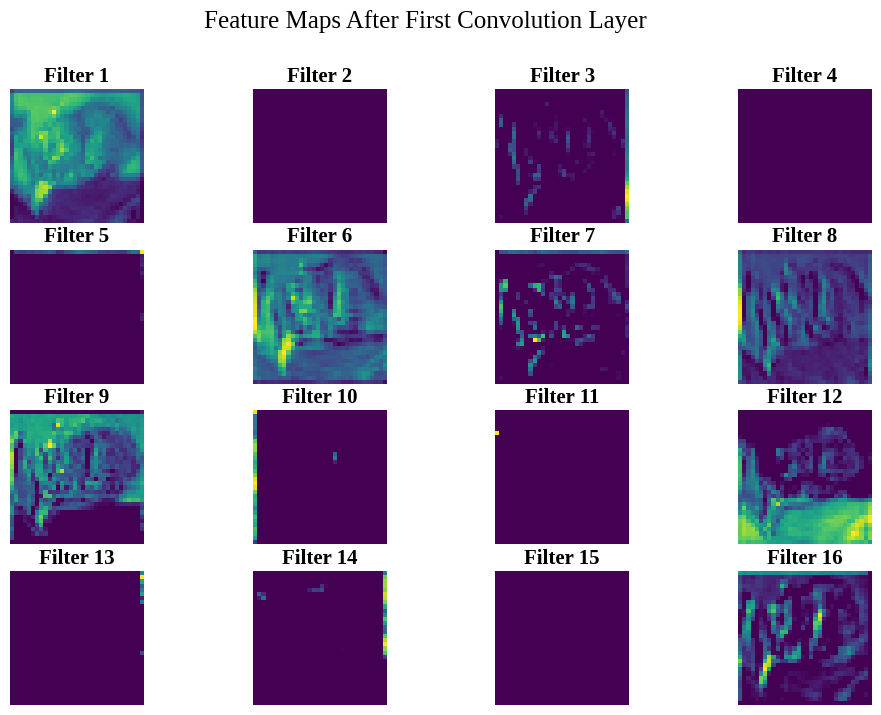

In [17]:
plt.figure(figsize=(12,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        feature_maps[0,:,:,i],
        cmap='viridis'
    )

    plt.title("Filter {}".format(i+1))

    plt.axis('off')

plt.suptitle("Feature Maps After First Convolution Layer")
plt.savefig("FeatureMaps.png")
plt.show()

# Task 5
## Compare
* Max Pooling
* Average Pooling
## Compare output size and accuracy.

# Task 6
# MaxPooling

## Input → Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → Dense → Softmax
# Train for
* Optimizer : Adam
* Epochs : 20
* Batch Size : 32

In [19]:
# Max Pooling
max_model = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',

        padding='same',
        input_shape=(32,32,3)
    ),
    MaxPooling2D(pool_size=(2,2))
])

print("Max Pooling")
print("Convolution Output Shape:", max_model.layers[0].output.shape)
print("Max Pooling Output Shape :", max_model.layers[1].output.shape)

# Average Pooling
avg_model = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),
    AveragePooling2D(pool_size=(2,2))
])
print("\nAverage Pooling")
print("Convolution Output Shape:", avg_model.layers[0].output.shape)
print("Max Pooling Output Shape :", avg_model.layers[1].output.shape)

Max Pooling
Convolution Output Shape: (None, 32, 32, 32)
Max Pooling Output Shape : (None, 16, 16, 32)

Average Pooling
Convolution Output Shape: (None, 32, 32, 32)
Max Pooling Output Shape : (None, 16, 16, 32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# MaxPooling
model = Sequential()
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history_max = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.4778 - loss: 1.4504 - val_accuracy: 0.5925 - val_loss: 1.1677
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 63ms/step - accuracy: 0.6238 - loss: 1.0676 - val_accuracy: 0.6343 - val_loss: 1.0393
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 94s 74ms/step - accuracy: 0.6733 - loss: 0.9273 - val_accuracy: 0.6601 - val_loss: 0.9750
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.7109 - loss: 0.8253 - val_accuracy: 0.6801 - val_loss: 0.9342
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 121s 55ms/step - accuracy: 0.7376 - loss: 0.7422 - val_accuracy: 0.6788 - val_loss: 0.9450
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.7673 - loss: 0.6647 - val_accuracy: 0.6794 - val_loss: 0.9591
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 57ms/step - accuracy: 0.7918 - loss: 0.5943 - val_accuracy: 0.6913 - val_loss: 0.9284
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.8140

# Max Pooling Accuracy
* Test Accuracy
* Training Accuracy
* Validation Accuracy

In [30]:
loss_max, accuracy_max = model.evaluate(X_test, y_test_cat, verbose=0)
print("MaxPooling")
print("Test Accuracy:", accuracy_max)

MaxPooling
Test Accuracy: 0.6700999736785889


In [31]:
print("Training Accuracy :", history_max.history['accuracy'][-1])
print("Validation Accuracy :", history_max.history['val_accuracy'][-1])

Training Accuracy : 0.9588249921798706
Validation Accuracy : 0.6748999953269958


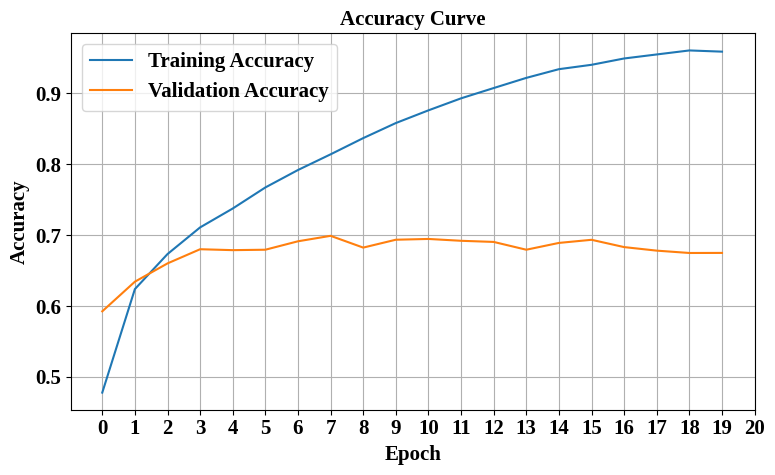

In [58]:
plt.figure(figsize=(8,5))
plt.plot(history_max.history['accuracy'], label='Training Accuracy')
plt.plot(history_max.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(ticks=range(0,21))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("AccuracyCurve.png")
plt.show()

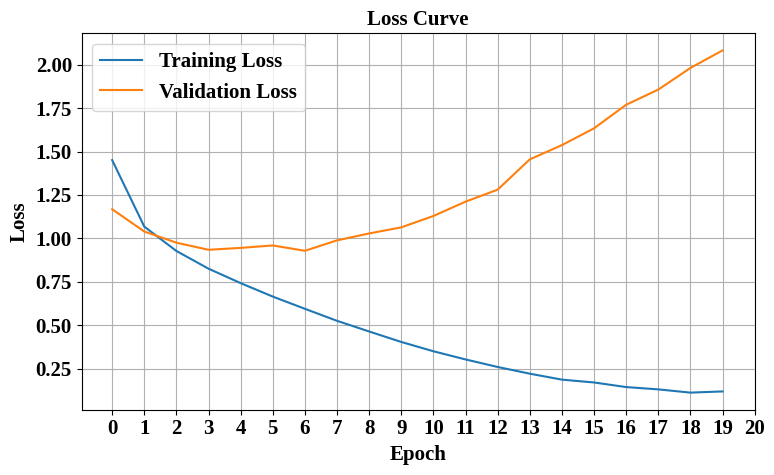

In [60]:
plt.figure(figsize=(8,5))

plt.plot(history_max.history['loss'], label='Training Loss')
plt.plot(history_max.history['val_loss'], label='Validation Loss')
plt.xticks(ticks=range(0,21))
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("LossCurve.png")
plt.show()

## Evaluation Metrics
* Precision
* Recall
* f1-score

In [61]:
# Get predictions from model
y_pred = model.predict(X_test)
predicted_labels = np.argmax(y_pred, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [62]:
precision = precision_score(
    true_labels,
    predicted_labels,
    average='weighted'
)

recall = recall_score(
    true_labels,
    predicted_labels,
    average='weighted'
)

f1 = f1_score(
    true_labels,
    predicted_labels,
    average='weighted'
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.6734823717083183
Recall    : 0.6701
F1 Score  : 0.6692512658859346


# Classification Report

In [63]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.76      0.64      0.70      1000
  Automobile       0.83      0.74      0.78      1000
        Bird       0.53      0.62      0.57      1000
         Cat       0.51      0.44      0.47      1000
        Deer       0.60      0.66      0.63      1000
         Dog       0.61      0.53      0.57      1000
        Frog       0.73      0.77      0.75      1000
       Horse       0.65      0.77      0.70      1000
        Ship       0.75      0.80      0.77      1000
       Truck       0.76      0.73      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



# Confusion Matrix

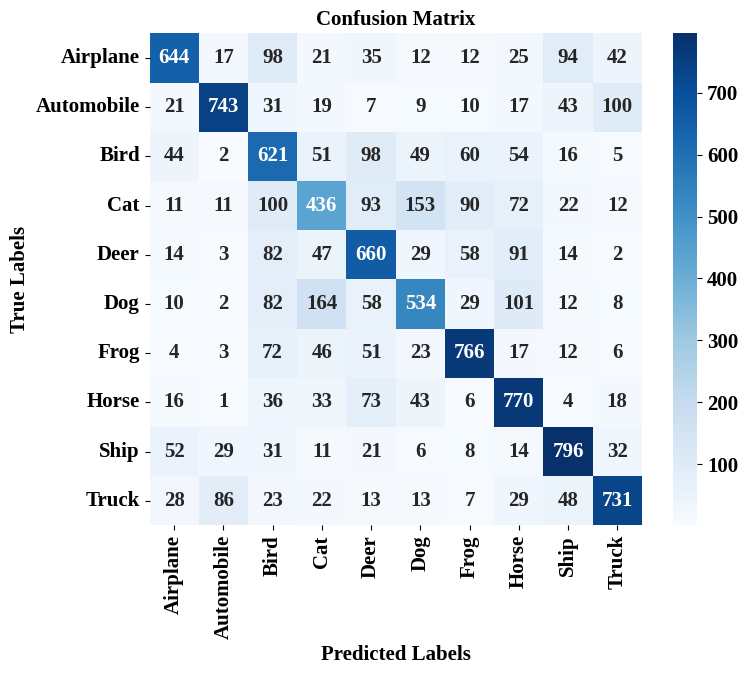

In [65]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("ConfusionMatrix.png")
plt.show()

# Average Pooling
## Compare output size and accuracy.

In [66]:
# Average Pooling
model = Sequential()
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

model.add(AveragePooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(AveragePooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [69]:
history_avg = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 51ms/step - accuracy: 0.4512 - loss: 1.5229 - val_accuracy: 0.5425 - val_loss: 1.2906
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.5827 - loss: 1.1767 - val_accuracy: 0.5951 - val_loss: 1.1496
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.6389 - loss: 1.0250 - val_accuracy: 0.6260 - val_loss: 1.0585
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 51ms/step - accuracy: 0.6755 - loss: 0.9224 - val_accuracy: 0.6616 - val_loss: 0.9760
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.7025 - loss: 0.8502 - val_accuracy: 0.6722 - val_loss: 0.9496
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.7258 - loss: 0.7799 - val_accuracy: 0.6865 - val_loss: 0.9078
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 88s 54ms/step - accuracy: 0.7436 - loss: 0.7203 - val_accuracy: 0.6938 - val_loss: 0.9059
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - accuracy: 0.7653 -

In [70]:
loss_avg, accuracy_avg = model.evaluate(X_test, y_test_cat, verbose=0)
print("AveragePooling Test Accuracy:", accuracy_avg)

AveragePooling Test Accuracy: 0.6775000095367432


In [71]:
print("AveragePooling Training Accuracy :", history_avg.history['accuracy'][-1])
print("AveragePooling Validation Accuracy :", history_avg.history['val_accuracy'][-1])

AveragePooling Training Accuracy : 0.9439250230789185
AveragePooling Validation Accuracy : 0.6814000010490417


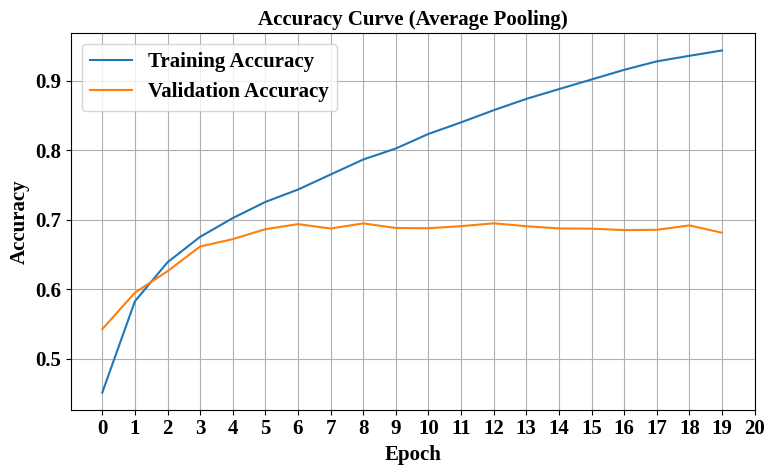

In [72]:
plt.figure(figsize=(8,5))
plt.plot(history_avg.history['accuracy'], label='Training Accuracy')
plt.plot(history_avg.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve (Average Pooling)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(ticks=range(0,21))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("AvgPooling_AccuracyCurve.png")
plt.show()

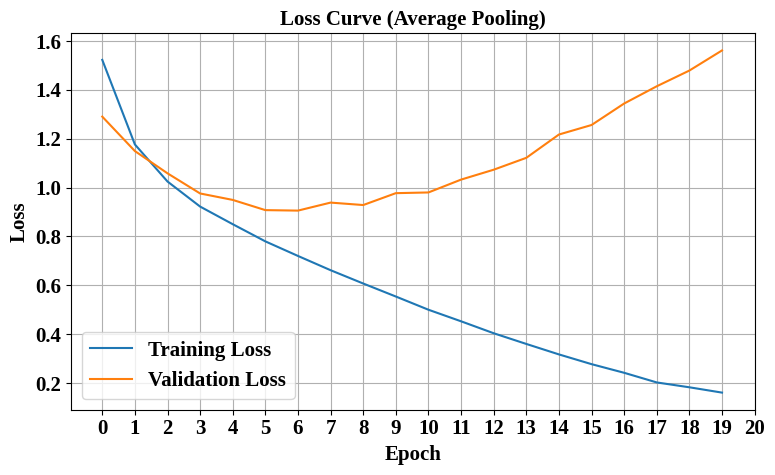

In [73]:
plt.figure(figsize=(8,5))

plt.plot(history_avg.history['loss'], label='Training Loss')
plt.plot(history_avg.history['val_loss'], label='Validation Loss')
plt.xticks(ticks=range(0,21))
plt.title("Loss Curve (Average Pooling)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("AvgPooling_LossCurve.png")
plt.show()

In [74]:
# Get predictions from model
y_pred = model.predict(X_test)
predicted_labels = np.argmax(y_pred, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


In [76]:
precision = precision_score(
    true_labels,
    predicted_labels,
    average='weighted'
)

recall = recall_score(
    true_labels,
    predicted_labels,
    average='weighted'
)

f1 = f1_score(
    true_labels,
    predicted_labels,
    average='weighted'
)

print("Precision (Average Pooling) :", precision)
print("Recall  (Average Pooling)  :", recall)
print("F1 Score (Average Pooling) :", f1)

Precision (Average Pooling) : 0.6781694807270129
Recall  (Average Pooling)  : 0.6775
F1 Score (Average Pooling) : 0.6763600072857694


In [78]:
print("Classification Report (Average Pooling)")
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

Classification Report (Average Pooling)
              precision    recall  f1-score   support

    Airplane       0.69      0.76      0.72      1000
  Automobile       0.83      0.74      0.78      1000
        Bird       0.55      0.59      0.57      1000
         Cat       0.51      0.46      0.48      1000
        Deer       0.67      0.56      0.61      1000
         Dog       0.56      0.57      0.56      1000
        Frog       0.69      0.79      0.74      1000
       Horse       0.74      0.74      0.74      1000
        Ship       0.79      0.80      0.80      1000
       Truck       0.76      0.76      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



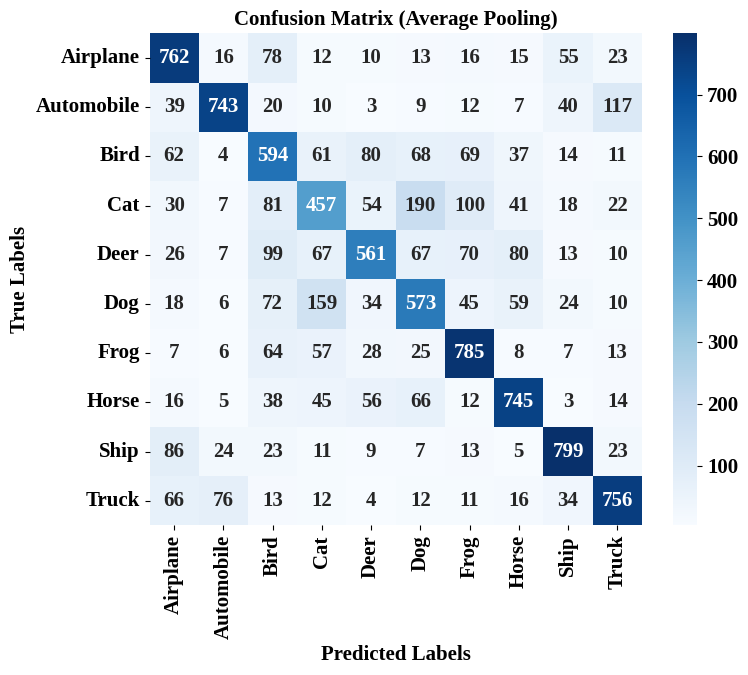

In [79]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix (Average Pooling)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("AvgPooling_ConfusionMatrix.png")
plt.show()